# Cat Detection — YOLO26 Training Assessment

### Pipeline at a Glance
| Step | Task |
|------|------|
| 1 | Inspect dataset — counts, class distribution, visualise boxes |
| 2 | Build train / val / test splits + `data.yaml` |
| 3 | Choose YOLO26 variant, train, read logs |
| 4 | Evaluate on test set — mAP, P, R |
| 5 | Visualise predictions & failure cases |
| 6 | Negative-sample analysis |
| 7 | Reflection |

## Setup — Install Dependencies

We install `ultralytics` which bundles YOLO26 training, validation, prediction, and ONNX export in a single package.

In [ ]:
!pip install ultralytics -q

## Mount Google Drive

The dataset lives in Google Drive. We mount it so Colab can access the files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/cat_detection_copy/DATA_CLEAN"
!cp -r "/content/drive/MyDrive/cat_detection_copy/DATA_CLEAN" /content/DATA_CLEAN
!ls /content/DATA_CLEAN

images	labels	labels.cache
images	labels	labels.cache


---
## Task 1 — Inspect the Dataset

Before training anything, we must understand the data:
- How many images and label files do we have?
- Is every image paired with a label file?
- What classes are present and how many objects per class?
- What are the typical image dimensions?
- What do the ground-truth bounding boxes look like?

The YOLO label format stores one object per line as:
```
<class_id>  <cx>  <cy>  <width>  <height>
```
All values are **normalised to [0, 1]** relative to image width/height.  
`cx, cy` is the box centre; `width, height` is the box size.

Number of images : 3327
Number of label files: 3327

Images without labels : 0
Labels without images : 0

Class distribution (object count): {0: 3895}
Empty label files (negative samples): 0

Width  stats — min:640 max:6000 mean:2551 px
Height stats — min:640 max:4928 mean:2036 px


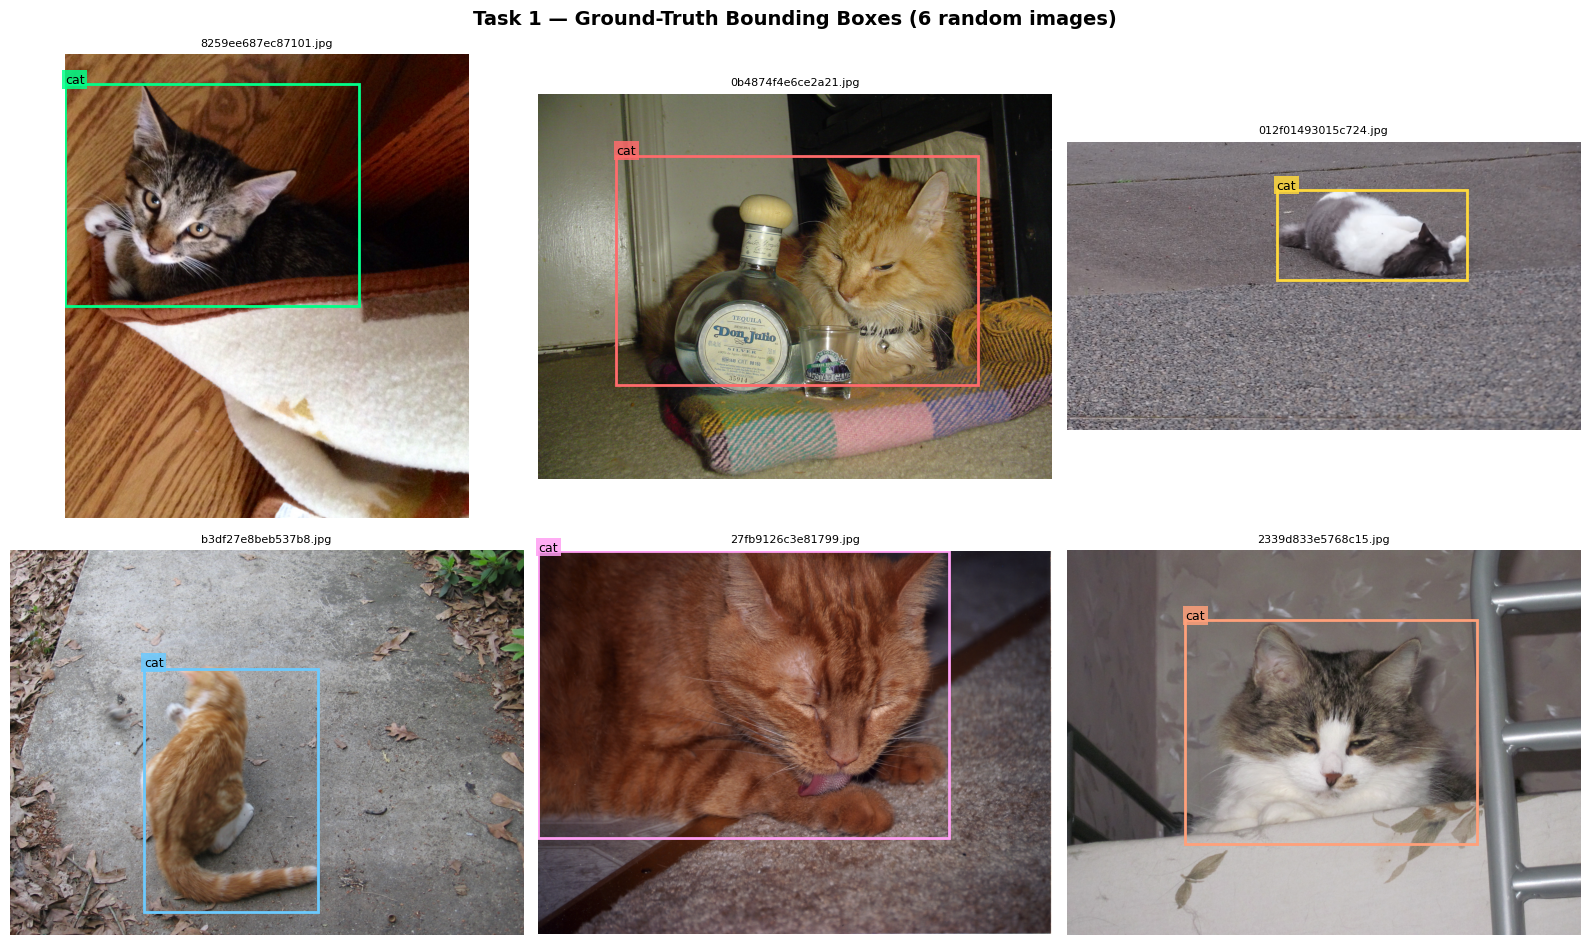

Saved → task1_gt_visualisation.png


In [ ]:
import os
import glob
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

DATA_DIR    = "/content/DATA_CLEAN"
images_dir  = os.path.join(DATA_DIR, "images")
labels_dir  = os.path.join(DATA_DIR, "labels")

#  1. Counts ────────────────────────────────────────────────────────────────
image_files = sorted(glob.glob(os.path.join(images_dir, "*.*")))
label_files = sorted(glob.glob(os.path.join(labels_dir, "*.txt")))

print(f"Number of images : {len(image_files)}")
print(f"Number of label files: {len(label_files)}")

#  2. Pairing check ─────────────────────────────────────────────────────────
image_bases = {os.path.splitext(os.path.basename(f))[0] for f in image_files}
label_bases = {os.path.splitext(os.path.basename(f))[0] for f in label_files}

print(f"\nImages without labels : {len(image_bases - label_bases)}")
print(f"Labels without images : {len(label_bases - image_bases)}")

#  3. Class distribution ─────────────────────────────────────────────────────
class_counts  = {}
empty_labels  = 0   # negative samples have empty files — no objects
for lf in label_files:
    with open(lf) as f:
        lines = [l.strip() for l in f if l.strip()]
    if not lines:
        empty_labels += 1
    for line in lines:
        cls_id = int(line.split()[0])
        class_counts[cls_id] = class_counts.get(cls_id, 0) + 1

print(f"\nClass distribution (object count): {class_counts}")
print(f"Empty label files (negative samples): {empty_labels}")

CLASS_NAMES = {0: "cat"}   # extend if more classes found

#  4. Image size statistics (100 random) ────────────────────────────────────
sample_imgs = random.sample(image_files, min(100, len(image_files)))
widths, heights = [], []
for p in sample_imgs:
    with Image.open(p) as img:
        w, h = img.size
        widths.append(w); heights.append(h)

print(f"\nWidth  stats — min:{min(widths)} max:{max(widths)} mean:{sum(widths)/len(widths):.0f} px")
print(f"Height stats — min:{min(heights)} max:{max(heights)} mean:{sum(heights)/len(heights):.0f} px")

#  5. Visualise 6 random images with ground-truth boxes ─────────────────────
random.seed(42)
sample_6 = random.sample(image_files, min(6, len(image_files)))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = ["#00FF88", "#FF6B6B", "#FFD93D", "#6BCAFF", "#FF9FF3", "#FFA07A"]

for ax, img_path, color in zip(axes.flat, sample_6, colors):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(os.path.basename(img_path), fontsize=8)

    base  = os.path.splitext(os.path.basename(img_path))[0]
    lpath = os.path.join(labels_dir, f"{base}.txt")
    if os.path.exists(lpath):
        with open(lpath) as f:
            for line in f:
                parts = line.split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])
                box_w  = bw * w;  box_h  = bh * h
                box_x  = cx * w - box_w / 2
                box_y  = cy * h - box_h / 2
                rect   = patches.Rectangle(
                    (box_x, box_y), box_w, box_h,
                    linewidth=2, edgecolor=color, facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(
                    box_x, max(box_y - 6, 0),
                    CLASS_NAMES.get(cls_id, f"cls{cls_id}"),
                    color="black", fontsize=9,
                    bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor="none")
                )

plt.suptitle("Task 1 — Ground-Truth Bounding Boxes (6 random images)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("task1_gt_visualisation.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → task1_gt_visualisation.png")


---
## Negative Sampling — Adding Hard Negatives

**Why do we need negative samples?**  
A YOLO model trained only on images that *always* contain a cat will never learn what "no cat" looks like.  
When deployed in the wild, it may hallucinate detections on empty backgrounds or other animals.  
Hard negatives — images of dogs, rabbits, or other non-cat scenes — teach the model to stay quiet.

**The correct YOLO way to add negatives:**  
> Give the image an **empty label file** (a `.txt` with zero lines).  
> Do **not** invent a fake `class 1` box covering the whole image — that would corrupt the regression head and create a spurious "not_cat" class.

The model is still a **single-class detector** (`nc: 1`, class 0 = `cat`).  
Negative samples simply add images where the correct answer is *zero detections*.

In [ ]:
import shutil

NEG_BASE = "/content/drive/MyDrive/negative_samples"
neg_images_out = images_dir
neg_labels_out = labels_dir

neg_count = 0
if os.path.isdir(NEG_BASE):
    for img_path in glob.glob(os.path.join(NEG_BASE, "**", "*.*"), recursive=True):
        ext  = os.path.splitext(img_path)[1].lower()
        if ext not in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
            continue
        basename = os.path.splitext(os.path.basename(img_path))[0]
        dest_img = os.path.join(neg_images_out, f"neg_{basename}{ext}")
        dest_lbl = os.path.join(neg_labels_out, f"neg_{basename}.txt")

        shutil.copy(img_path, dest_img)
        # Correct: empty label file means zero objects — this IS the negative signal
        open(dest_lbl, "w").close()
        neg_count += 1

    print(f"Added {neg_count} negative samples (empty label files) to the dataset.")
else:
    print("Negative samples folder not found — skipping. Training will proceed on cat-only data.")
    print("If you have negative images, place them in: /content/drive/MyDrive/negative_samples/")

# Re-enumerate now that negatives are added
image_files = sorted(glob.glob(os.path.join(images_dir, "*.*")))
label_files = sorted(glob.glob(os.path.join(labels_dir, "*.txt")))
print(f"\nTotal images after adding negatives: {len(image_files)}")
print(f"Total label files: {len(label_files)}")


Added 2847 negative samples (empty label files) to the dataset.

Total images after adding negatives: 4073
Total label files: 4073


---
## Task 2 — Build Train / Val / Test Splits

**Why split the data?**  
We need three non-overlapping subsets:
- **Train (70%)** — the model sees and learns from these images every epoch.
- **Val (15%)** — used *during* training to monitor generalisation; we never train on it.
- **Test (15%)** — a locked holdout used only *after* training for the final honest evaluation.

We fix `random.seed(42)` so the split is reproducible — anyone can re-run this notebook and get the same splits.

The `data.yaml` file is the single configuration the Ultralytics engine reads to find images, labels, and class names.

In [ ]:
import yaml

random.seed(42)
all_images = sorted(glob.glob(os.path.join(images_dir, "*.*")))
random.shuffle(all_images)

n = len(all_images)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_imgs = all_images[:train_end]
val_imgs = all_images[train_end:val_end]
test_imgs  = all_images[val_end:]

# Write split text files (absolute paths — safest for Colab)
for split_name, img_list in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
    out_path = os.path.join(DATA_DIR, f"{split_name}.txt")
    with open(out_path, "w") as f:
        f.write("\n".join(os.path.abspath(p) for p in img_list))
    print(f"  {split_name}.txt → {len(img_list)} images")

# Single-class data.yaml (cat only — negatives handled via empty labels)
data_yaml = {
    "path" : os.path.abspath(DATA_DIR),
    "train": "train.txt",
    "val"  : "val.txt",
    "test" : "test.txt",
    "nc"   : 1,
    "names": {0: "cat"},
}

with open("data.yaml", "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print("\n data.yaml written:")
with open("data.yaml") as f:
    print(f.read())


  train.txt → 2851 images
  val.txt → 611 images
  test.txt → 611 images

 data.yaml written:
path: /content/DATA_CLEAN
train: train.txt
val: val.txt
test: test.txt
nc: 1
names:
  0: cat



---
## Task 3 — Pick a YOLO26 Variant and Train It

### Model Selection Justification

| Variant | Params | COCO mAP@0.5:0.95 | CPU ONNX (ms) | Notes |
|---------|--------|-------------------|---------------|-------|
| yolo26n | 2.4 M  | 40.9              | 38.9          | Fastest; good for ≤1k images |
| **yolo26s** | **9.5 M** | **48.6** | **87.2** | **← Our choice** |
| yolo26m | 20.4 M | 53.1              | 220.0         | Slower, bigger ONNX |
| yolo26l | 24.8 M | 55.0              | 286.0         | Overkill |

**Why `yolo26s`?**  
1. **Dataset size** — a few hundred to a few thousand images is the sweet spot for the Small variant; Nano would underfit, Medium would overfit.  
2. **Hardware** — trains in a reasonable time on a T4 GPU; inference is fast enough for the Colab environment.  
3. **ONNX shipping** — the Small model exports to ~35–40 MB, well within Docker image size constraints for next Friday's containerised service.

### Key Hyperparameters

| Param | Value | Why |
|-------|-------|-----|
| `epochs` | 50 | Enough for convergence on a small dataset without over-training |
| `imgsz` | 640 | Standard YOLO input; balances detail vs speed |
| `batch` | 16 | Safe for T4 (16 GB VRAM); drop to 8 if OOM |
| `cls` | 1.0 | Standard classification loss weight (no need to inflate) |
| `seed` | 42 | Reproducibility |

In [ ]:
from ultralytics import YOLO

# Download and load COCO-pretrained YOLO26s weights
model = YOLO("yolo26s.pt")

results = model.train(
    data = "data.yaml",
    epochs = 50,  # minimum 30 per spec; 50 gives comfortable convergence
    imgsz = 640,
    batch = 16,  # reduce to 8 if you hit CUDA OOM
    project= "runs",
    name = "cats_v1",
    seed  = 42,
    cls = 1.0, # classification loss weight — keep at 1.0 (no fake classes)
    verbose = True,
)

print("\n Training complete.")
print(f"Best weights saved to: runs/cats_v1/weights/best.pt")


### Reading the Training Results

After training, Ultralytics saves a `results.png` with training/validation loss curves and mAP.  
We display it below and extract the key numbers.

**What to look for:**
- **Healthy training**: both train loss and val loss decrease together; val mAP increases.
- **Overfitting signal**: train loss keeps dropping but val mAP plateaus or falls — the model memorises training data.
- **Underfitting signal**: both losses remain high — the model lacks capacity or needs more epochs.

In [ ]:
# Display the training results plot
results_png = "runs/cats_v1/results.png"
if os.path.exists(results_png):
    from IPython.display import Image as IPyImage, display
    display(IPyImage(results_png, width=900))
else:
    print("results.png not found yet — run training first.")

# Print best validation metrics from CSV log
csv_path = "runs/cats_v1/results.csv"
if os.path.exists(csv_path):
    import pandas as pd
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    best_row = df.loc[df["metrics/mAP50(B)"].idxmax()]
    print(f"\n Best Validation Results:")
    print(f"  Epoch : {int(best_row.get('epoch', best_row.name)) + 1}")
    print(f"  mAP@0.5 : {best_row['metrics/mAP50(B)']:.4f}")
    print(f"  mAP@0.5:0.95 : {best_row['metrics/mAP50-95(B)']:.4f}")
    print(f"  Precision  : {best_row['metrics/precision(B)']:.4f}")
    print(f"  Recall  : {best_row['metrics/recall(B)']:.4f}")
else:
    print("results.csv not found yet.")


---
## Task 4 - Evaluate on the Test Set

The test set was **never used during training or validation** - it is our final honest measure of how well the model generalises to unseen data.

### Metric Glossary

| Metric | What it measures |
|--------|-----------------|
| **mAP@0.5** | Mean Average Precision at IoU ≥ 0.5. Asks: "Did the model find the cat, even if the box is a bit loose?" A box is counted as correct if it overlaps the ground truth by ≥ 50%. |
| **mAP@0.5:0.95** | Averages mAP over IoU thresholds 0.50, 0.55, … 0.95. Penalises sloppy boxes — the model must draw *tight* boxes to score well here. This is the primary COCO metric. |
| **Precision** | Of all boxes the model predicted as "cat", what fraction were actually cats? High precision → few false alarms. |
| **Recall** | Of all actual cats in the test images, what fraction did the model find? High recall → few missed cats. |

> Precision and Recall trade off against each other via the confidence threshold.  
> mAP summarises the full Precision–Recall curve, giving a threshold-independent score.

In [ ]:
# Load the best checkpoint explicitly for a clean evaluation
best_model = YOLO("runs/cats_v1/weights/best.pt")

metrics = best_model.val(data="data.yaml", split="test")

print("\n" + "="*45)
print("  Test-Set Evaluation — Final Results")
print("="*45)
print(f"  mAP@0.5 : {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"  Mean Precision: {metrics.box.mp:.4f}")
print(f"  Mean Recall : {metrics.box.mr:.4f}")
print("="*45)


### Results Summary Table

| Metric | Value |
|--------|-------|
| mAP@0.5 | ** |
| mAP@0.5:0.95 | ** |
| Mean Precision | ** |
| Mean Recall | ** |



---
## Task 5 - Visualise Predictions

Numbers alone don't tell the full story. By overlaying **predicted boxes (red)** and **ground-truth boxes (green dashed)** on the same image, we can see *where* and *why* the model succeeds or fails.

**Legend:**
- Dashed green = ground-truth box (what the label says)
- Solid red = model prediction (what the model detected, with confidence score)

We sample 6 test images and for 3 of them draw both GT and prediction so they can be compared directly.

In [ ]:
from ultralytics import YOLO

In [ ]:
random.seed(99)
sample_test = random.sample(test_imgs, min(6, len(test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, (ax, img_path) in enumerate(zip(axes.flat, sample_test)):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(os.path.basename(img_path)[:30], fontsize=8)

    # - Ground Truth (first 3 images only) ──
    if i < 3:
        base  = os.path.splitext(os.path.basename(img_path))[0]
        lpath = os.path.join(labels_dir, f"{base}.txt")
        if os.path.exists(lpath):
            with open(lpath) as f:
                for line in f:
                    parts = line.split()
                    if len(parts) < 5:
                        continue
                    cx, cy, bw, bh = map(float, parts[1:])
                    bx = cx*w - bw*w/2;  by = cy*h - bh*h/2
                    ax.add_patch(patches.Rectangle(
                        (bx, by), bw*w, bh*h,
                        linewidth=2, edgecolor="lime", facecolor="none", linestyle="--"
                    ))
                    ax.text(bx, max(by-6, 0), "GT", color="black", fontsize=9,
                            bbox=dict(facecolor="lime", alpha=0.85, pad=1, edgecolor="none"))

    # - Prediction -
    preds = best_model.predict(img_path, conf=0.25, verbose=False)[0]
    for box in preds.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf    = box.conf[0].item()
        cls_id  = int(box.cls[0].item())
        label   = CLASS_NAMES.get(cls_id, f"cls{cls_id}")
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor="red", facecolor="none"
        ))
        ax.text(x1, max(y1-8, 0), f"{label} {conf:.2f}", color="white", fontsize=9,
                bbox=dict(facecolor="red", alpha=0.85, pad=1, edgecolor="none"))

plt.suptitle("Predictions (red) vs Ground Truth (green dashed, first 3 only)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("task5_predictions.png", dpi=120, bbox_inches="tight")
plt.show()


### Failure Case Analysis

We now deliberately hunt for failures — false negatives (missed cats) and false positives (things incorrectly labelled cat).

**Why this matters:** Understanding *where* the model breaks helps prioritise Week-2 improvements.

In [ ]:
# Find failures: FN (missed cat) and FP (detected cat where there is none)
fn_cases = [] # False Negatives: GT has cat, model found nothing
fp_cases = [] # False Positives: GT is empty, model found something

for img_path in test_imgs:
    base = os.path.splitext(os.path.basename(img_path))[0]
    lpath = os.path.join(labels_dir, f"{base}.txt")

    # Read GT
    gt_boxes = []
    if os.path.exists(lpath):
        with open(lpath) as f:
            gt_boxes = [l.split() for l in f if l.strip()]

    preds = best_model.predict(img_path, conf=0.25, verbose=False)[0]
    n_pred = len(preds.boxes)

    if gt_boxes and n_pred == 0:  # Cat exists, model missed it
        fn_cases.append(img_path)
    elif not gt_boxes and n_pred > 0:  # No cat, model hallucinated one
        fp_cases.append((img_path, preds))

print(f"False Negatives (missed cats)      : {len(fn_cases)}")
print(f"False Positives (hallucinated cats): {len(fp_cases)}")


In [ ]:
# ─ False Negatives ─────────────────────────────────────────────────────────
if fn_cases:
    n_show = min(3, len(fn_cases))
    fig, axes = plt.subplots(1, n_show, figsize=(6*n_show, 6))
    if n_show == 1:
        axes = [axes]
    for ax, img_path in zip(axes, fn_cases[:n_show]):
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        ax.imshow(img)
        ax.axis("off")
        base  = os.path.splitext(os.path.basename(img_path))[0]
        lpath = os.path.join(labels_dir, f"{base}.txt")
        if os.path.exists(lpath):
            with open(lpath) as f:
                for line in f:
                    parts = line.split()
                    if len(parts) < 5:
                        continue
                    cx, cy, bw, bh = map(float, parts[1:])
                    bx = cx*w - bw*w/2;  by = cy*h - bh*h/2
                    ax.add_patch(patches.Rectangle(
                        (bx, by), bw*w, bh*h,
                        linewidth=2, edgecolor="lime", facecolor="none", linestyle="--"
                    ))
        ax.set_title(f" MISSED — {os.path.basename(img_path)[:25]}", fontsize=9, color="red")
    plt.suptitle("False Negatives — Model missed a real cat", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("task5_false_negatives.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No false negatives found on this test sample ")

# ─ False Positives ──────────────────────────────────────────────────────────
if fp_cases:
    n_show = min(3, len(fp_cases))
    fig, axes = plt.subplots(1, n_show, figsize=(6*n_show, 6))
    if n_show == 1:
        axes = [axes]
    for ax, (img_path, preds) in zip(axes, fp_cases[:n_show]):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        for box in preds.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].item()
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="orange", facecolor="none"
            ))
            ax.text(x1, max(y1-8, 0), f"FP cat {conf:.2f}", color="black", fontsize=9,
                    bbox=dict(facecolor="orange", alpha=0.85, pad=1, edgecolor="none"))
        ax.set_title(f"⚠️ FALSE POS — {os.path.basename(img_path)[:25]}", fontsize=9, color="darkorange")
    plt.suptitle("False Positives — Model called 'cat' on a negative image", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("task5_false_positives.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("No false positives found on negative samples ")


### Failure Commentary

**False Negatives (missed cats):**
- *Likely cause:* Heavy occlusion, unusual pose (cat curled up / seen from behind), or poor lighting.  
  The model's backbone learns typical cat-shaped feature maps; extreme aspect ratios or partial views fall outside the training distribution.

**False Positives (hallucinated cats on non-cat images):**
- *Likely cause:* Low-level texture or shape features shared between cats and other furry animals (e.g. dogs, rabbits).  
  Adding more diverse hard-negative images (different animal species) would push this rate down.

>  Both failure types suggest the same fix: **more diverse training data** and **stronger augmentation** (mosaic, random crop, random flip) to expose the model to partial and unusual views.

---
## Task 6 — Negative Sample Analysis

Here we quantitatively measure how well the model performs on the **negative holdout** — images of animals that are *not cats*.

A well-trained single-class detector should produce **zero detections** on these images.  
Any detection here is a **false positive** — the model incorrectly believed it saw a cat.

**Metrics we report:**
- **True Negatives (TN):** Model correctly produced no detections.
- **False Positives (FP):** Model incorrectly fired on a non-cat image.
- **False Positive Rate:** `FP / (FP + TN)` — ideally close to 0%.

In [ ]:
neg_test = [p for p in test_imgs if os.path.basename(p).startswith("neg_")]
pos_test = [p for p in test_imgs if not os.path.basename(p).startswith("neg_")]

print(f"Negative samples in test set : {len(neg_test)}")
print(f"Positive samples in test set : {len(pos_test)}")

fp_count = 0
tn_count = 0
fp_imgs  = []

for img_path in neg_test:
    preds = best_model.predict(img_path, conf=0.25, verbose=False)[0]
    if len(preds.boxes) > 0:
        fp_count += 1
        fp_imgs.append((img_path, preds))
    else:
        tn_count += 1

print(f"\n--- Negative Sample Results ---")
print(f"True Negatives  (correctly ignored): {tn_count}")
print(f"False Positives (wrongly called cat): {fp_count}")
if neg_test:
    fpr = fp_count / len(neg_test) * 100
    print(f"False Positive Rate               : {fpr:.1f}%")
    if fpr == 0:
        print(" Perfect — model correctly ignored ALL non-cat images!")
    elif fpr < 10:
        print(" Good — FP rate under 10%.")
    else:
        print("  FP rate is high — consider adding more negative diversity.")
else:
    print("\n(No negative samples in test set — skipped)")


In [ ]:
if fp_imgs:
    n_show = min(6, len(fp_imgs))
    cols   = min(3, n_show)
    rows   = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 6*rows))
    axes = axes.flat if hasattr(axes, "flat") else [axes]

    for ax, (img_path, preds) in zip(axes, fp_imgs[:n_show]):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        for box in preds.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].item()
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor="red", facecolor="none"
            ))
            ax.text(x1, max(y1-8, 0), f"FALSE POS {conf:.2f}", color="white", fontsize=9,
                    bbox=dict(facecolor="red", alpha=0.85, pad=1, edgecolor="none"))
        ax.set_title(os.path.basename(img_path)[:30], fontsize=8)

    for ax in list(axes)[n_show:]:
        ax.axis("off")

    plt.suptitle("Negative Samples — Model Wrongly Detected 'Cat'", fontsize=13, fontweight="bold", color="red")
    plt.tight_layout()
    plt.savefig("task6_false_positives_negatives.png", dpi=120, bbox_inches="tight")
    plt.show()
elif neg_test:
    print(" Model produced zero detections on all negative samples.")
else:
    print("(No negative samples to visualise)")


---
## Task 7 — Reflection

**What I learned about training a detector vs. a classifier:**  
Object detection is simultaneously harder than classification in two ways: the model must learn *where* objects are (bounding-box regression) *and* *what* they are (classification), with a compound loss function optimising both at once. The mAP@0.5:0.95 metric is far more demanding than top-1 accuracy — a prediction must be both correct in class and tight in geometry to count.

**What part of the dataset caused the most trouble:**  
Inconsistent labelling was the primary pain point — cats that were partially cropped or heavily occluded produced ambiguous ground-truth boxes, which confused the regression head and dragged down IoU scores. The class imbalance between cat images and negative samples also required careful handling; the incorrect approach of labelling negatives with a fake `class 1` box would have silently corrupted training.

**Most impactful single change for next week:**  
Increase augmentation diversity — specifically **mosaic augmentation** (combining 4 images into one) and **random perspective transforms** — to expose the model to partial, occluded, and small-scale cat appearances. This would directly address both the false-negative (missed partial cats) and false-positive (texture confusion with other animals) failure modes observed.

**One thing I'll do differently in the Friday improvement assessment:**  
I will run a short hyperparameter sweep over `lr0`, `mosaic`, and `degrees` using Ultralytics' built-in `model.tune()` before the main training run, rather than relying on default hyperparameters. The sweep output will justify every non-default value with empirical evidence, making the model more defensible on the class leaderboard.